# initiating 

In [77]:
import random
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import PercentFormatter
import networkx as nx
import pandas as pd
import warnings
from ipynb.fs.full.Reading_CloudNetworks import SNetwork_DictList , Networks_DictList



In [125]:
def plot(results, title,victim,names,type):
    if type =="NCC": TData=2 ; titl='NCC'
    elif type =="LCC": TData=3; titl='$|N_{LCC}| / |N|$ '
    elif type =="diam": TData=4; titl='Diameter '
    else:
       warnings.warn("Warning...uncorrect type /n type parameter only takes NCC,LCC or diam /n value this function only plot: NCC,LCC and diameter, ") 
    fig = plt.figure(dpi=600)
    fig, ax = plt.subplots()
    markers = ['*', 'D', 'x'] # three shape of markers for the 3 type of cloud networks 
    marker_idx=-1
    colors =["#FF1B0F", "#FF470FFF","#BD0900","#FF2828BA","#b0bf1a","#17e93a","#4aa500","#3B6829","#42e8f3","#429ef3","#5068f0","#003bdd"] # four raneg of colors for the three the 3 type of cloud networks 
    for d in range(len(results)):
        data = results[d]
        x = [(item[1])*100 for item in data]
        y = [item[TData] for item in data]
        if d%4==0: marker_idx+=1
        # ax.xaxis.set_major_formatter(mtick.PercentFormatter(100,0)) 
        ax.plot(x, y,marker=markers[marker_idx],color=colors[d], linewidth=0.5, markersize=6,label=names[d])

    ax.set_xlabel(f'{victim} Removed (%)')
    ax.set_ylabel(f'{titl}')
    ax.set_title(f'{title}  ')
    plt.legend()
    plt.legend(bbox_to_anchor=(0.5, 1.35), loc='upper center',ncol=3)

In [ ]:
# only return a single batche of the specific percentage (no need to pay attacnhes to teh last node Will only remove 80%) 
# num_batches> no necessary 
def return_batch(lst,per):
    batch_size = round(len(lst)*per)
    # return a slice of the list 
    batch=lst[0:batch_size]
    return batch 

In [71]:
def properties(G):
#return properties of graph G if the gaint compponet did not disapear or only contined 1 node 

    Connected_components = list(nx.connected_components(G))
    numConnected_components= len(Connected_components)
    if numConnected_components > 0:
        subG = G.subgraph(max(Connected_components, key=len))   
        if len(subG.nodes())>1: 
            # for Avrage Shortes Path and diameter wil we will only consider the gaint component  
            ASP = nx.average_shortest_path_length(subG)
            degrees = nx.degree_centrality(G)
            # de-normalizing degree values to calculate the avarage 
            dList= degrees.values()
            maxpoosibleD=G.number_of_nodes()-1
            deNormalize= [x * maxpoosibleD for x in dList]
            avg_degree= sum(deNormalize)/G.number_of_nodes()
            diam = nx.diameter(subG)
            ACC = nx.average_clustering(G)
            numEdges= len(G.edges()) #does not work with edges attacks only for networks proporties 

            return [numConnected_components,len(subG) ,round(ASP,2), round(diam,2),round(ACC,2), round(avg_degree,2), numEdges]
        
        else:
            return None, None,None,None, None,None,None
        
    else:
        # Handle the case when there are no connected components (keep as our method also use LLC as an andicator to when shall we stop the attack, see [our paper])
        return None, None, None,None, None,None,None

# Random Attacks

In [121]:
# defining global variables 

networks = Networks_DictList()
pers=[0.0,0.01,0.05,0.1,0.15,0.2]
names=[]
for network in networks:
        names.append(network['name'])

## Nodes Random Attacks 

In [ ]:
# networks = Networks_DictList()
# pers=[0.0,0.01,0.05,0.1,0.15,0.2]

# results = []
# for network in networks:
#     i=0
#     G = network['graph'].copy()
#     result = []
#     for i in range(len(pers)):
#         V = list(G.nodes)
#         # random.shuffle(V)
#         print(V)
#         batche = return_batch(V,pers[i])
#         print(batche)
#         G.remove_nodes_from(batche)
#         umConnected_components,largest_componentSize ,ASP, diam,ACC, avg_degree,numEdges= properties(G)
#         result.append([network['name'],pers[i], umConnected_components ,round(largest_componentSize/len(G),2) ,ASP, diam,ACC, avg_degree])
#         i+=1
#     results.append(result)

#     print(results)

In [127]:
def randomN_AttckSim():
    # defining variables 
    results = [] 
    # alliterating through all the networks 
    for network in networks:
        G = network['graph'].copy()
        result = [] #to store the properties of a networking while removing nodes 
        i=0
        for i in range(len(pers)):
            V = list(G.nodes)
            random.shuffle(V)
            batche = return_batch(V,pers[i])
            print(batche)
            G.remove_nodes_from(batche)
            umConnected_components,largest_componentSize ,ASP, diam,ACC, avg_degree,numEdges= properties(G)
            result.append([network['name'],pers[i], umConnected_components/len(G) ,round(largest_componentSize/len(G),2) ,ASP, diam,ACC, avg_degree])
        results.append(result)
    return results

In [ ]:
VRA_Table = pd.DataFrame()
VRA_name= [];VRA_numofBatch=[];VRA_umConnected_components=[];VRA_LCC=[];VRA_diam= [];VRA_ASP=[]; VRA_ACC=[]; VRA_avg_degree=[]
rndV_results = randomN_AttckSim()


for result in  rndV_results:
    for batches in result:
        VRA_name.append(batches[0])
        VRA_numofBatch.append(f"{((batches[1])*100)} %")
        VRA_umConnected_components.append(batches[2])
        VRA_LCC.append(batches[3])
        VRA_diam.append(batches[5])
        VRA_ASP.append(batches[4])
        VRA_ACC.append(batches[6])
        VRA_avg_degree.append(batches[7])

VRA_Table["Networks"]=VRA_name; VRA_Table["Percentage of nodes removed"]= VRA_numofBatch
VRA_Table["Number of Connected Components"]= VRA_umConnected_components
VRA_Table["largest_component/N"]=VRA_LCC ;VRA_Table["Diameter of the LCC"]=VRA_diam
VRA_Table["avrage shortes path of the LCC"] = VRA_ASP; VRA_Table["Average Clustering Coefficient"] =VRA_ACC
VRA_Table["avrage Degress"] = VRA_avg_degree 

[]
[79]
[44, 74, 28, 47, 82]
[50, 18, 66, 55, 76, 46, 10, 43, 96]
[51, 61, 5, 33, 49, 25, 63, 37, 69, 6, 72, 88, 17]
[93, 27, 60, 92, 35, 36, 84, 8, 67, 89, 20, 26, 87, 68]
[]
[925, 394, 945, 840, 993, 384, 239, 736, 760, 872]
[757, 63, 21, 703, 889, 778, 834, 908, 490, 522, 5, 859, 932, 467, 85, 679, 841, 170, 275, 532, 79, 938, 283, 765, 110, 732, 473, 535, 612, 158, 468, 164, 754, 553, 401, 656, 505, 444, 880, 56, 767, 811, 276, 154, 243, 991, 348, 146, 801, 66]
[918, 410, 252, 598, 432, 871, 980, 763, 139, 601, 994, 853, 816, 996, 699, 641, 269, 587, 939, 13, 354, 326, 187, 476, 317, 651, 109, 878, 121, 957, 52, 288, 979, 632, 28, 534, 868, 630, 475, 362, 655, 372, 371, 143, 408, 843, 965, 985, 982, 130, 94, 437, 89, 374, 417, 875, 129, 603, 160, 565, 363, 23, 248, 153, 733, 927, 201, 563, 95, 82, 781, 484, 513, 518, 741, 813, 76, 564, 133, 50, 2, 958, 75, 646, 943, 226, 815, 510, 789, 836, 267, 561, 297, 86]
[669, 441, 7, 16, 837, 998, 492, 838, 211, 583, 814, 773, 805, 578, 542, 

In [90]:
VRA_Table

,Networks,Percentage of nodes removed,Number of Connected Components,largest_component/N,Diameter of the LCC,avrage shortes path of the LCC,Average Clustering Coefficient,avrage Degress
0,"Fat_tree, Nodes 100 seed 76",0.0 %,1,1.00,9,4.47,0.06,3.06
1,"Fat_tree, Nodes 100 seed 76",1.0 %,1,1.00,9,4.47,0.06,3.07
2,"Fat_tree, Nodes 100 seed 76",5.0 %,2,0.99,10,4.64,0.06,2.96
3,"Fat_tree, Nodes 100 seed 76",10.0 %,6,0.94,11,4.94,0.04,2.45
4,"Fat_tree, Nodes 100 seed 76",15.0 %,15,0.78,14,5.51,0.02,1.86
...,...,...,...,...,...,...,...,...
67,"Microservice, Nodes 10000 seed 6516",1.0 %,47,0.99,6,4.00,0.01,5.42
68,"Microservice, Nodes 10000 seed 6516",5.0 %,164,0.97,6,4.02,0.01,5.15
69,"Microservice, Nodes 10000 seed 6516",10.0 %,434,0.91,6,4.04,0.01,4.72
70,"Microservice, Nodes 10000 seed 6516",15.0 %,692,0.84,6,4.13,0.00,3.99


In [ ]:
# VRA_Table.to_csv('Random_nodesAttcak.csv')

<Figure size 3840x2880 with 0 Axes>

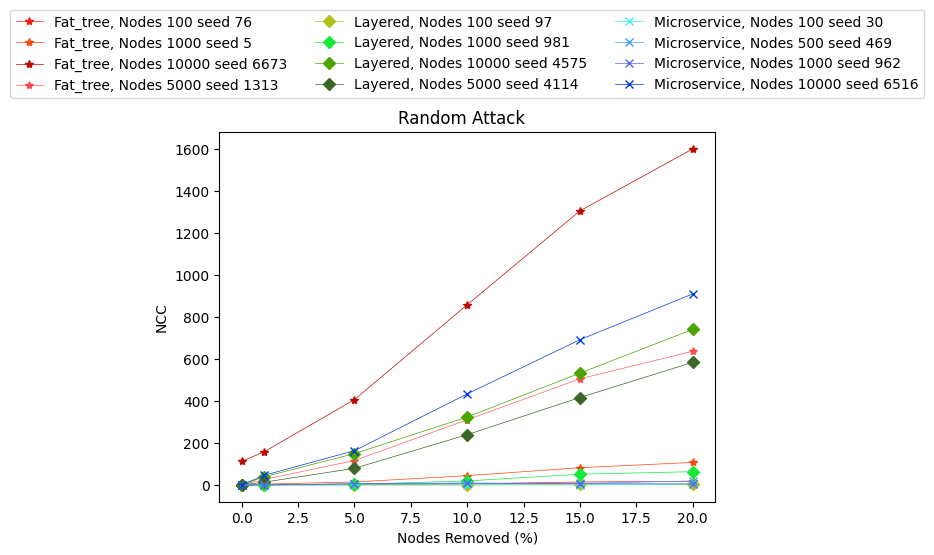

<Figure size 3840x2880 with 0 Axes>

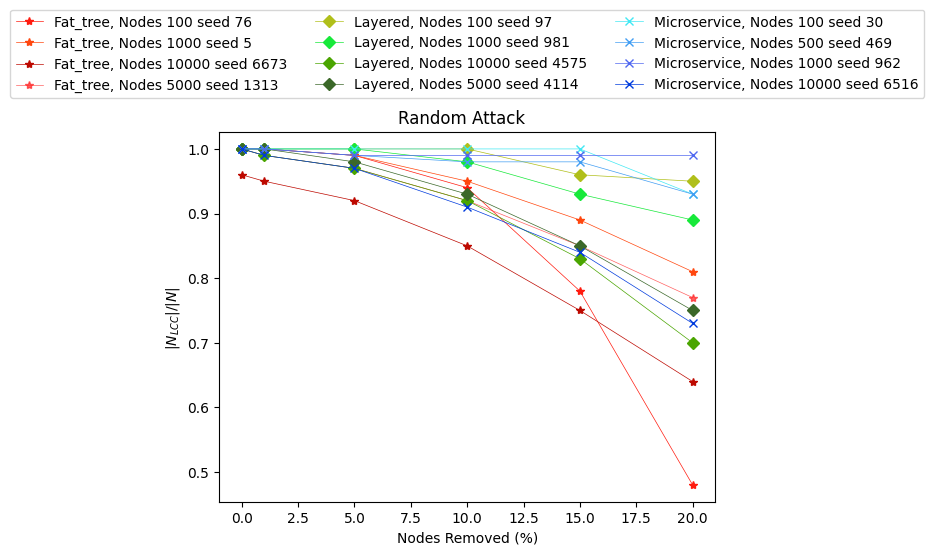

<Figure size 3840x2880 with 0 Axes>

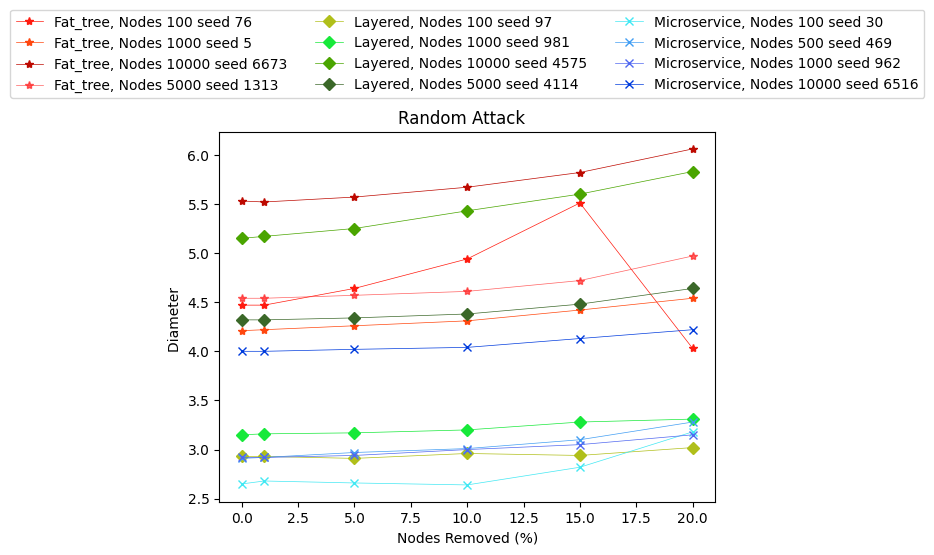

In [ ]:
Plot_types=['NCC',"LCC","diam"]
for type in Plot_types:
    plot(rndV_results, 'Random Attack', 'Nodes',names,type)   

## Edges Random Attacks 

In [ ]:
# networks = Networks_DictList()
# names=[]
# for network in networks:
#         names.append(network['name'])

# def randomE_AttckSim():
#     results = []
#     for network in networks:
#         G = network['graph'].copy()
#         E = list(G.edges)
#         random.shuffle(E)
#         batches = batch_list_per(E,0.1)
#         result = []
#         for b in range(len(batches)):
#             G.remove_edges_from(batches[b])            
#             if b<5:
#                 umConnected_components,largest_componentSize ,ASP, diam,ACC, avg_degree,numEdges= properties(G)
#                 result.append([network['name'],b, umConnected_components ,largest_componentSize/len(G) ,ASP, diam,ACC, avg_degree])

#         results.append(result)
#     return results

In [93]:
def randomE_AttckSim():
    # defining variables 
    results = [] 
    # alliterating through all the networks 
    for network in networks:
        G = network['graph'].copy()
        result = [] #to store the properties of a networking while removing nodes 
        i=0
        for i in range(len(pers)):
            E = list(G.edges)
            random.shuffle(E)
            batche = return_batch(E,pers[i])
            G.remove_edges_from(batche)
            umConnected_components,largest_componentSize ,ASP, diam,ACC, avg_degree,numEdges= properties(G)
            result.append([network['name'],pers[i], umConnected_components ,round(largest_componentSize/len(G),2) ,ASP, diam,ACC, avg_degree])
            
        results.append(result)
    return results

In [94]:
ERA_Table = pd.DataFrame()
ERA_name= [];ERA_numofBatch=[];ERA_umConnected_components=[];ERA_LCC=[];ERA_diam= [];ERA_ASP=[]; ERA_ACC=[]; ERA_avg_degree=[]
rndE_results = randomE_AttckSim()


for result in  rndE_results:
    for batches in result:
        ERA_name.append(batches[0])
        ERA_numofBatch.append(f"{((batches[1])*100)} %")
        ERA_umConnected_components.append(batches[2])
        ERA_LCC.append(batches[3])
        ERA_diam.append(batches[5])
        ERA_ASP.append(batches[4])
        ERA_ACC.append(batches[6])
        ERA_avg_degree.append(batches[7])

ERA_Table["Networks"]=ERA_name; ERA_Table["Percentage of Edges removed"]= ERA_numofBatch
ERA_Table["Number of Connected Components"]= ERA_umConnected_components
ERA_Table["largest_component/N"]=ERA_LCC ;ERA_Table["Diameter of the LCC"]=ERA_diam
ERA_Table["avrage shortes path of the LCC"] = ERA_ASP; ERA_Table["Average Clustering Coefficient"] =ERA_ACC
ERA_Table["avrage Degress"] = ERA_avg_degree 

ERA_Table

,Networks,Percentage of Edges removed,Number of Connected Components,largest_component/N,Diameter of the LCC,avrage shortes path of the LCC,Average Clustering Coefficient,avrage Degress
0,"Fat_tree, Nodes 100 seed 76",0.0 %,1,1.00,9,4.47,0.06,3.06
1,"Fat_tree, Nodes 100 seed 76",1.0 %,1,1.00,9,4.52,0.06,3.02
2,"Fat_tree, Nodes 100 seed 76",5.0 %,4,0.96,9,4.70,0.06,2.86
3,"Fat_tree, Nodes 100 seed 76",10.0 %,8,0.92,10,5.03,0.05,2.58
4,"Fat_tree, Nodes 100 seed 76",15.0 %,14,0.85,14,5.98,0.04,2.20
5,"Fat_tree, Nodes 100 seed 76",20.0 %,24,0.69,17,6.58,0.04,1.76
6,"Layered, Nodes 100 seed 97",0.0 %,1,1.00,5,2.93,0.15,5.46
7,"Layered, Nodes 100 seed 97",1.0 %,1,1.00,5,2.94,0.14,5.40
8,"Layered, Nodes 100 seed 97",5.0 %,3,0.98,5,2.96,0.13,5.12
9,"Layered, Nodes 100 seed 97",10.0 %,8,0.93,5,3.03,0.11,4.60


In [ ]:
ERA_Table.to_csv('Random_EdgesAttcak.csv')

<Figure size 3840x2880 with 0 Axes>

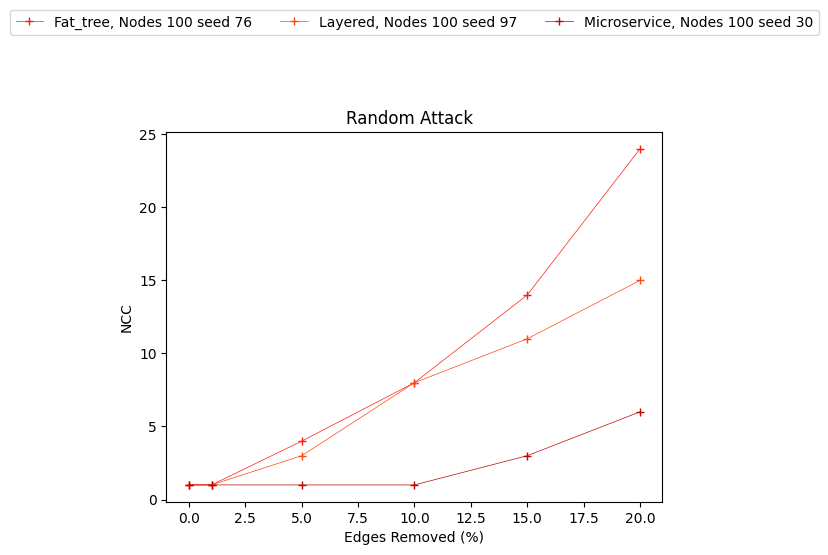

<Figure size 3840x2880 with 0 Axes>

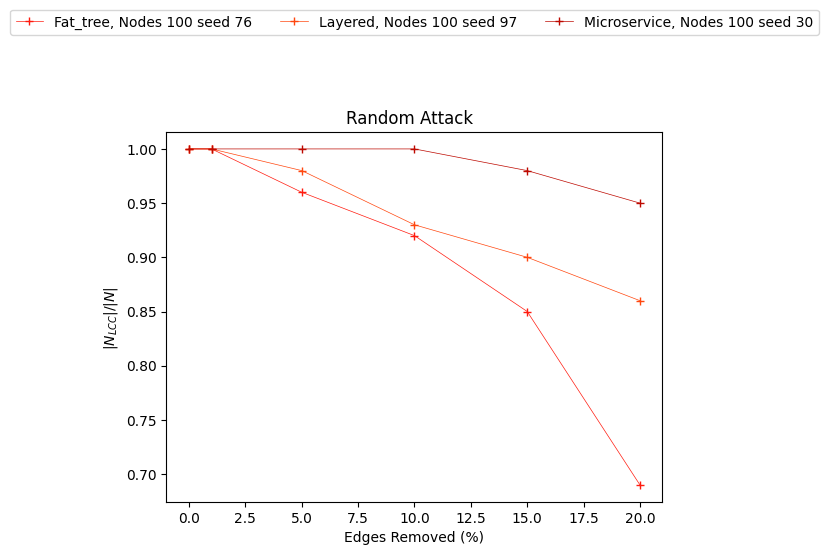

<Figure size 3840x2880 with 0 Axes>

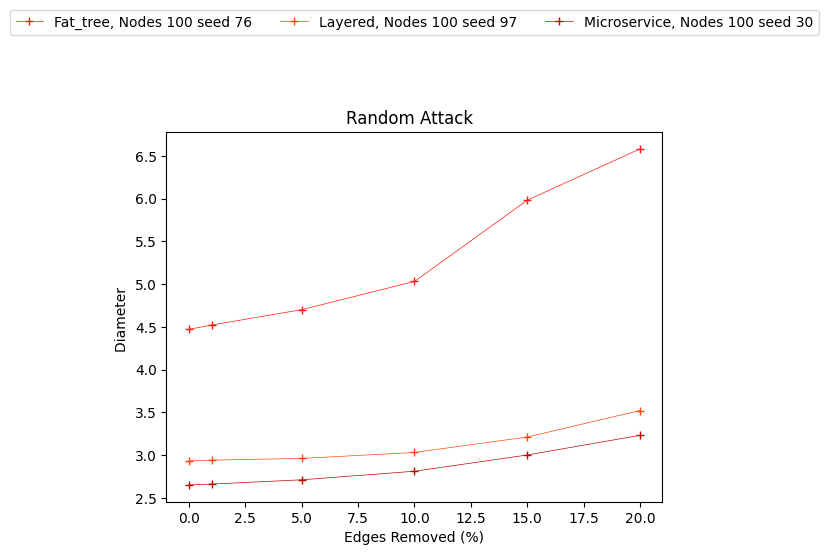

In [98]:
Plot_types=['NCC',"LCC","diam"]
for type in Plot_types:
    plot(rndE_results, 'Random Attack', 'Edges',names,type)

# Targeted Attacks

In [65]:
centr = ['Degree','Betweenness']
pers=[0.0,0.01,0.05,0.1,0.15,0.2]


#return an order list of only the only one CI specified by the paramenter low to hight for recusive method 
def CI_Node_orderd_list(G,centrality ):
    CI_Dict =centrality(G)
    CI_sortedDict = {k: v for k, v in sorted(CI_Dict.items(), key=lambda item: item[1],reverse=True)}
    CI_sortedList= list(CI_sortedDict.keys())
    return CI_sortedList  

#  return an order edge list of only the only one CI specified by the paramenter low to hight 
def weighted_edges(G, centrality): #  from [8] for degree only + other if for betweeness
    '''return a weighted edges equations from paper 11'''
    W = []

    if centrality == nx.betweenness_centrality:
        CI_Dict = nx.edge_betweenness_centrality(G)
        CI_sortedDict = {k: v for k, v in sorted(CI_Dict.items(), key=lambda item: item[1],reverse=True)}
        for u,v in G.edges():
            W.append([u, v, CI_sortedDict[u,v]] )
    else:
        CI_Dict = centrality(G)
        for u,v in G.edges():
            W.append([u, v, CI_Dict[u]*CI_Dict[v]])
    return sorted(W, key=lambda x: x[2])


In [ ]:
# def recalculateRecursionGen(network,G,batches,batches_size,centrality,i,results, victim):

#     print("network before removal of 10%",network['name'])
#     if victim == "Node Attack":
#         R = batches[i] # Nodes to be removed...
#         G.remove_nodes_from(R)
#     else:
#         R = [(u,v) for u,v,_ in batches[i]] # edges to be removed...
#         G.remove_edges_from(R)

#     if len(results)<5:
#         umConnected_components,largest_componentSize ,ASP, diam,ACC, avg_degree,numEdges= properties(G)
#         if largest_componentSize:
#             print("network After removal of 10%",network['name'])
#             results.append([network['name'],len(results)+1, umConnected_components ,largest_componentSize/len(G),ASP, diam,ACC, avg_degree])       
    
#     i-=1

#     if victim == "Node Attack":
#         Ranked_lists = CI_Node_orderd_list2(G,centrality)
#     else:    
#         Ranked_lists = weighted_edges(G,centrality) 
    
#     neWbatches = simple_batching(Ranked_lists,batches_size) # batchin the nodes into an BN of batches 
#     if  i<=0  : return results
#     else: return recalculateRecursionGen(network,G, neWbatches,batches_size,centrality, i ,results,victim)

In [66]:
def recalculateRecursionGen(network,G,i,centrality,results, victim):
    if victim == "Node Attack":
        Ranked_lists = CI_Node_orderd_list(G,centrality)
    else:    
        Ranked_lists = weighted_edges(G,centrality) 
    
    batche = return_batch(Ranked_lists,pers[i])

    if victim == "Node Attack":
        G.remove_nodes_from(batche) # remove Nodes...
    else:
        R = [(u,v) for u,v,_ in batche] # remove edges...
        G.remove_edges_from(R)

    umConnected_components,largest_componentSize ,ASP, diam,ACC, avg_degree,numEdges= properties(G)
    if largest_componentSize:
        print("network After removal of ",pers[i],"of",network['name'])
        results.append([network['name'],pers[i], umConnected_components ,round(largest_componentSize/len(G),2),round(ASP,2), round(diam,2),round(ACC,2), round(avg_degree,2)])       
    i+=1
    if  i>=len(pers)  : return results
    else: return recalculateRecursionGen(network,G,i,centrality ,results,victim)

## Nodes Targeted Attacks 

In [ ]:
#recalculating network cencentrality values after removaling a specific percentage of the network 
 
networks = Networks_DictList(test=True)
names=[]
for network in networks:
        names.append(network['name'])       
def simulationREC(centrality):
    results = []  
    for network in networks:
        G = network['graph'].copy()
        i=0
        result =recalculateRecursionGen(network,G,i,centrality,[],"Node Attack")
        results.append(result)

    return results

network After removal of  0.0 of Fat_tree, Nodes 100 seed 76
network After removal of  0.01 of Fat_tree, Nodes 100 seed 76
network After removal of  0.05 of Fat_tree, Nodes 100 seed 76
network After removal of  0.1 of Fat_tree, Nodes 100 seed 76
network After removal of  0.15 of Fat_tree, Nodes 100 seed 76
network After removal of  0.2 of Fat_tree, Nodes 100 seed 76
network After removal of  0.0 of Layered, Nodes 100 seed 97
network After removal of  0.01 of Layered, Nodes 100 seed 97
network After removal of  0.05 of Layered, Nodes 100 seed 97
network After removal of  0.1 of Layered, Nodes 100 seed 97
network After removal of  0.15 of Layered, Nodes 100 seed 97
network After removal of  0.2 of Layered, Nodes 100 seed 97
network After removal of  0.0 of Microservice, Nodes 100 seed 30
network After removal of  0.01 of Microservice, Nodes 100 seed 30
network After removal of  0.05 of Microservice, Nodes 100 seed 30
network After removal of  0.1 of Microservice, Nodes 100 seed 30
networ

,Networks,Percentage of nodes removed,Number of Connected Components,largest_component/N,Diameter,avrage shortes path,Average Clustering Coefficient,avrage Degress
0,"Fat_tree, Nodes 100 seed 76",0.0 %,1,1.00,9,4.47,0.06,3.06
1,"Fat_tree, Nodes 100 seed 76",1.0 %,1,1.00,11,5.02,0.06,2.95
2,"Fat_tree, Nodes 100 seed 76",5.0 %,7,0.73,14,5.26,0.07,2.57
3,"Fat_tree, Nodes 100 seed 76",10.0 %,20,0.27,9,3.62,0.08,1.95
4,"Fat_tree, Nodes 100 seed 76",15.0 %,37,0.10,4,2.19,0.09,1.28
5,"Fat_tree, Nodes 100 seed 76",20.0 %,49,0.05,2,1.33,0.00,0.31
6,"Layered, Nodes 100 seed 97",0.0 %,1,1.00,5,2.93,0.15,5.46
7,"Layered, Nodes 100 seed 97",1.0 %,5,0.96,5,3.01,0.07,5.09
8,"Layered, Nodes 100 seed 97",5.0 %,36,0.63,5,2.48,0.04,4.00
9,"Layered, Nodes 100 seed 97",10.0 %,37,0.58,5,2.87,0.03,2.54


<Figure size 3840x2880 with 0 Axes>

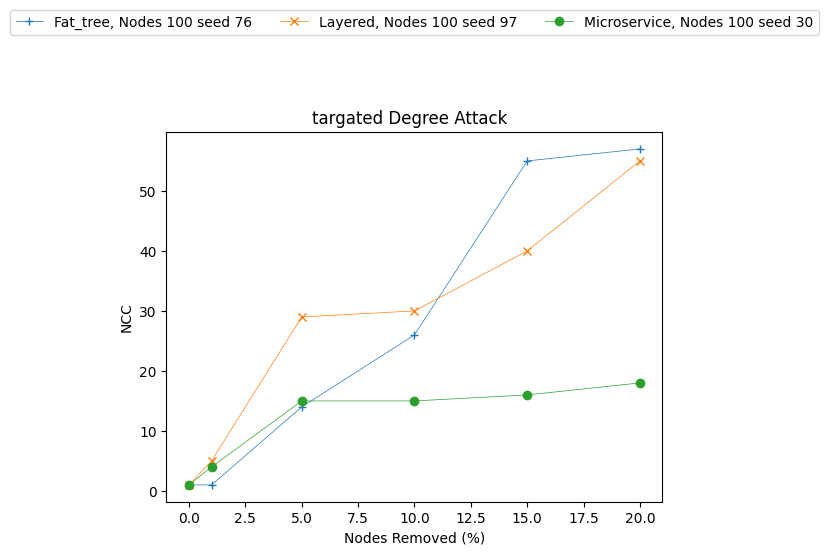

<Figure size 3840x2880 with 0 Axes>

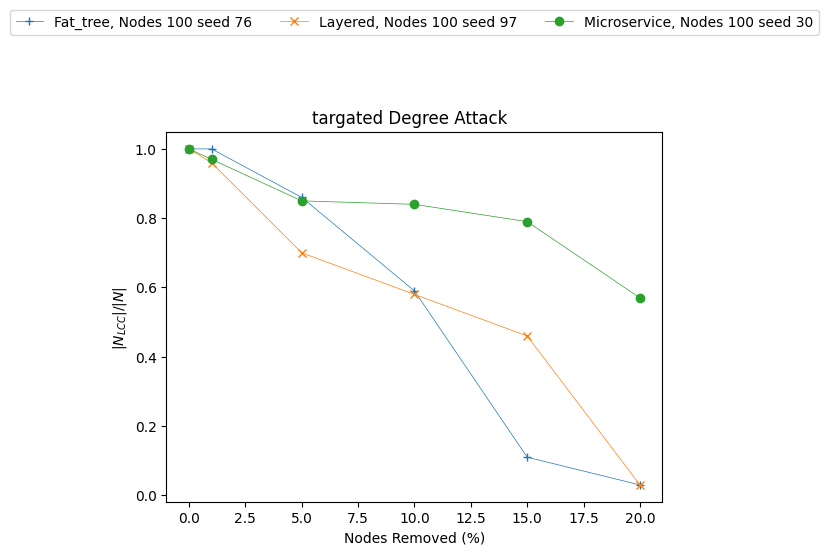

<Figure size 3840x2880 with 0 Axes>

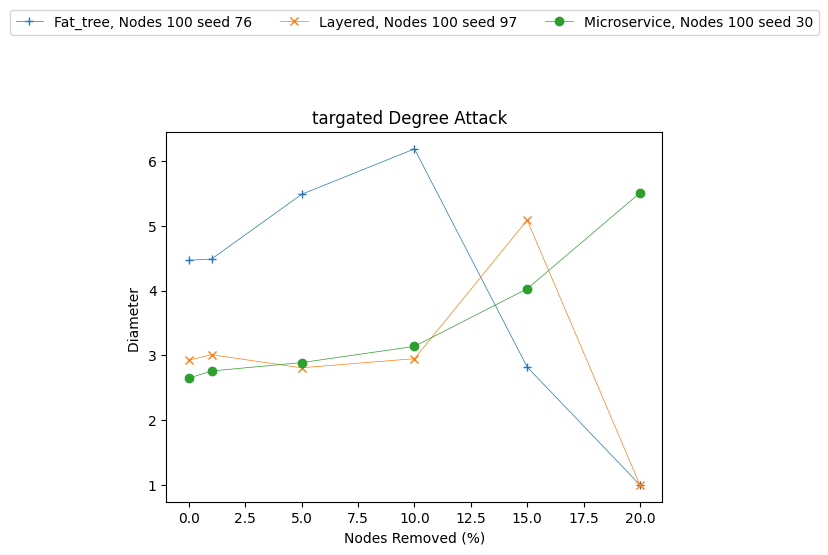

<Figure size 3840x2880 with 0 Axes>

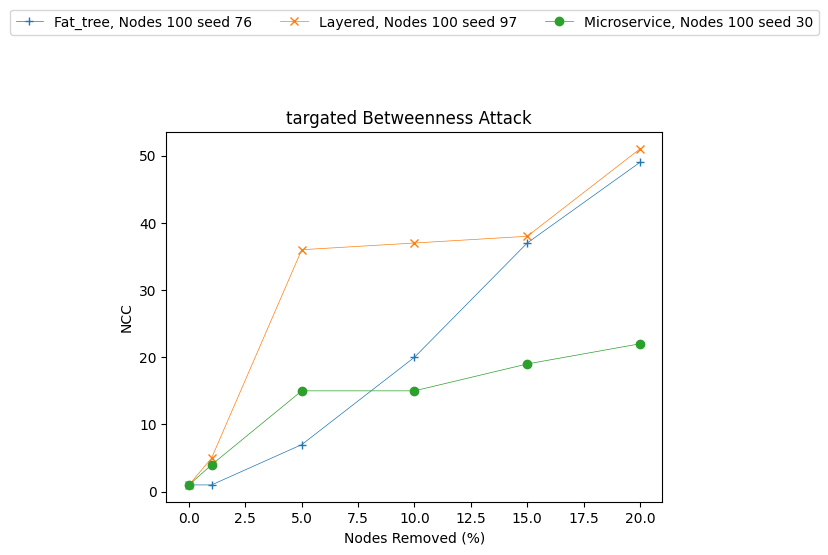

<Figure size 3840x2880 with 0 Axes>

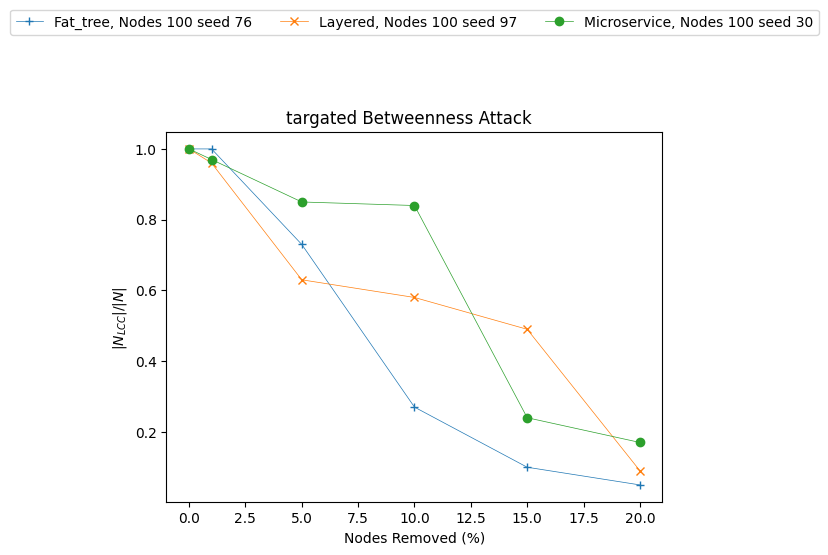

<Figure size 3840x2880 with 0 Axes>

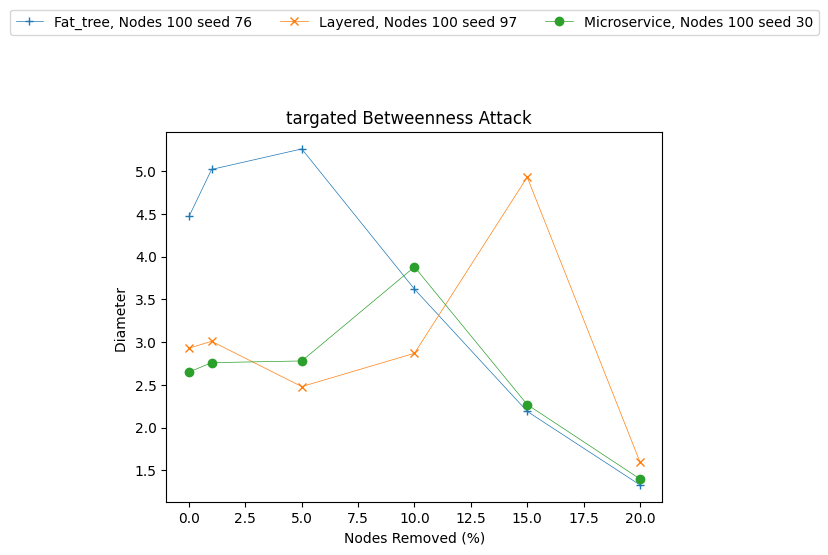

In [68]:
centralities = [nx.degree_centrality, nx.betweenness_centrality]
for i in range(len(centralities)):
    
    TA_results = simulationREC(centralities[i])

    Plot_types=['NCC',"LCC","diam"]
    for type in Plot_types:
        plot(TA_results, f'targated {centr[i]} Attack', 'Nodes',names,type)
        
    
    VTA_Table = pd.DataFrame()
    VTA_name= [];VTA_per=[];VTA_umConnected_components=[];VTA_LCC=[];VTA_diam= [];VTA_ASP=[]; VTA_ACC=[]; VTA_avg_degree=[]
    for result in  TA_results:
        for batches in result:
            VTA_name.append(batches[0])
            VTA_per.append(f"{((batches[1])*100)} %")
            VTA_umConnected_components.append(batches[2])
            VTA_LCC.append(batches[3])
            VTA_diam.append(batches[5])
            VTA_ASP.append(batches[4])
            VTA_ACC.append(batches[6])
            VTA_avg_degree.append(batches[7])

    VTA_Table["Networks"]=VTA_name; VTA_Table["Percentage of nodes removed"]= VTA_per
    VTA_Table["Number of Connected Components"]= VTA_umConnected_components
    VTA_Table["largest_component/N"]=VTA_LCC ;VTA_Table["Diameter"]=VTA_diam
    VTA_Table["avrage shortes path"] = VTA_ASP; VTA_Table["Average Clustering Coefficient"] =VTA_ACC
    VTA_Table["avrage Degress"] = VTA_avg_degree
    VTA_Table
    # VTA_Table.to_csv(f'Targated_{centr[i]}_nodesAttcak.csv')
VTA_Table

## Edges Targeted Attacks 

In [ ]:
networks = Networks_DictList()
names=[]
for network in networks:
    names.append(network['name'])
        
def E_simulationREC(centrality):
    results = []  
    for network in networks:
        G = network['graph'].copy()
        i=0
        result =recalculateRecursionGen(network,G,i,centrality,[],"Edge attck")
        results.append(result)

    return results

In [ ]:
centralities = [nx.degree_centrality, nx.betweenness_centrality]
Plot_types=['NCC',"LCC","diam"]
for i in range(len(centralities)):
    ETA_results = E_simulationREC(centralities[i],0.1)   

    for type in Plot_types:
        plot(ETA_results, f'targated {centr[i]} Attack', 'Edges',names,type)
    
    ETA_Table = pd.DataFrame()
    ETA_name= [];ETA_per=[];ETA_umConnected_components=[];ETA_LCC=[];ETA_diam= [];ETA_ASP=[]; ETA_ACC=[]; ETA_avg_degree=[]
    for result in  ETA_results:
        for batches in result:
            ETA_name.append(batches[0])
            ETA_per.append(f"{((batches[1])*100)} %")
            ETA_umConnected_components.append(batches[2])
            ETA_LCC.append(batches[3])
            ETA_diam.append(batches[5])
            ETA_ASP.append(batches[4])
            ETA_ACC.append(batches[6])
            ETA_avg_degree.append(batches[7])

    ETA_Table["Networks"]=ETA_name; ETA_Table["Percentage of nodes removed"]= ETA_per
    ETA_Table["Number of Connected Components"]= ETA_umConnected_components
    ETA_Table["largest_component/N"]=ETA_LCC ;ETA_Table["Diameter"]=ETA_diam
    ETA_Table["avg shortes path"] = ETA_ASP; ETA_Table["Average Clustering Coefficient"] =ETA_ACC
    ETA_Table["avg Degress"] = ETA_avg_degree
    # ETA_Table.to_csv(f'Targated {centr[i]}_EdgeAttcak.csv')
ETA_Table